# LLM API Cost Analysis for Text-to-SQL Tasks

This notebook calculates the average cost per task for different LLM models used in Text-to-SQL generation.

**Metrics Calculated:**
- Input token count (from prompts/instructions)
- Output token count (from generated SQL)
- Average cost per task (USD)
- Total cost per dataset and model

**Supported Models:**
- OpenAI: GPT-4o, GPT-4o-mini, GPT-5, GPT-5-mini
- DeepSeek: deepseek-chat, deepseek-coder
- Google: Gemini Pro, Gemma models
- Anthropic: Claude models

## 1. Import Required Libraries

In [1]:
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For token counting
try:
    import tiktoken
    TIKTOKEN_AVAILABLE = True
except ImportError:
    print("Warning: tiktoken not installed. Using character-based approximation.")
    print("Install with: pip install tiktoken")
    TIKTOKEN_AVAILABLE = False

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")
print(f"✓ Tiktoken available: {TIKTOKEN_AVAILABLE}")

✓ Libraries imported successfully
✓ Tiktoken available: True


## 2. Define Model Pricing Configuration

Pricing as of October 2025 (USD per 1M tokens)

In [2]:
# Model pricing in USD per 1M tokens
# Format: {"model_name": {"input": price_per_1m_input_tokens, "output": price_per_1m_output_tokens}}

MODEL_PRICING = {
    # OpenAI Models
    # "gpt-4o": {"input": 2.50, "output": 10.00},
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    # "gpt-4-turbo": {"input": 10.00, "output": 30.00},
    # "gpt-4": {"input": 30.00, "output": 60.00},
    # "gpt-3.5-turbo": {"input": 0.50, "output": 1.50},
    "gpt-5": {"input": 1.25, "output": 10.00},  # Estimated
    "gpt-5-mini": {"input": 0.25, "output": 2.00},  # Estimated
    
    # Anthropic Claude Models
    "claude-sonnet-4-5": {"input": 3.00, "output": 15.00},  # Latest Claude Sonnet 4.5
    # "claude-sonnet-4": {"input": 3.00, "output": 15.00},
    # "claude-3-5-sonnet-20241022": {"input": 3.00, "output": 15.00},
    # "claude-3-5-sonnet-20240620": {"input": 3.00, "output": 15.00},
    # "claude-3-opus-20240229": {"input": 15.00, "output": 75.00},
    # "claude-3-sonnet-20240229": {"input": 3.00, "output": 15.00},
    # "claude-3-haiku-20240307": {"input": 0.25, "output": 1.25},

    # Google Gemini
    "gemini-2.5-pro": {"input": 2.5, "output": 15.00},
    "gemini-2.5-flash": {"input": 0.3, "output": 2.50},
    # "gemini-2.0-flash-exp": {"input": 0.00, "output": 0.00},  # Free during preview
    # "gemini-1.5-pro-latest": {"input": 1.25, "output": 5.00},
    # "gemini-1.5-flash-latest": {"input": 0.075, "output": 0.30},
    # "gemini-1.5-flash-002": {"input": 0.075, "output": 0.30},
    # "gemini-1.5-pro-002": {"input": 1.25, "output": 5.00},
    
    # DeepSeek Models
    # "deepseek-chat": {"input": 0.28, "output": 0.42},
    "deepseek-coder": {"input": 0.28, "output": 0.42},
    "deepseek-reasoner": {"input": 0.28, "output": 0.42},
    
    # Google Models (via DeepInfra)
    "google-gemma-3-4b-it": {"input": 0.04, "output": 0.08},
    "google-gemma-3-27b-it": {"input": 0.09, "output": 0.16},
    
    # # Meta LLaMA Models (via DeepInfra)
    # "meta-llama/Meta-Llama-3.1-8B-Instruct": {"input": 0.06, "output": 0.06},
    # "meta-llama/Meta-Llama-3.1-70B-Instruct": {"input": 0.35, "output": 0.40},
    # "meta-llama/Meta-Llama-3.1-405B-Instruct": {"input": 2.70, "output": 2.70},
    
    # Qwen Models (via DeepInfra)
    "qwen2.5-coder-7b": {"input": 0.14, "output": 0.28},
    "qwen2.5-14b": {"input": 0.14, "output": 0.42},
    
    # Specialized SQL Models
    # "defog/llama-3-sqlcoder-8b": {"input": 0.06, "output": 0.06},  # Via DeepInfra
    # "Snowflake/Arctic-Text2SQL-R1-7B": {"input": 0.06, "output": 0.06},  # Via DeepInfra
}

# Display pricing table
pricing_df = pd.DataFrame.from_dict(MODEL_PRICING, orient='index')
pricing_df = pricing_df.reset_index().rename(columns={'index': 'Model'})
pricing_df['Total (input+output)'] = pricing_df['input'] + pricing_df['output']
pricing_df = pricing_df.sort_values('Total (input+output)')

print("=" * 80)
print("MODEL PRICING CONFIGURATION (USD per 1M tokens)")
print("=" * 80)
display(pricing_df.style.format({
    'input': '${:.2f}',
    'output': '${:.2f}',
    'Total (input+output)': '${:.2f}'
}).background_gradient(subset=['Total (input+output)'], cmap='RdYlGn_r'))

MODEL PRICING CONFIGURATION (USD per 1M tokens)


,Model,input,output,Total (input+output)
8,google-gemma-3-4b-it,$0.04,$0.08,$0.12
9,google-gemma-3-27b-it,$0.09,$0.16,$0.25
10,qwen2.5-coder-7b,$0.14,$0.28,$0.42
11,qwen2.5-14b,$0.14,$0.42,$0.56
6,deepseek-coder,$0.28,$0.42,$0.70
7,deepseek-reasoner,$0.28,$0.42,$0.70
0,gpt-4o-mini,$0.15,$0.60,$0.75
2,gpt-5-mini,$0.25,$2.00,$2.25
5,gemini-2.5-flash,$0.30,$2.50,$2.80
1,gpt-5,$1.25,$10.00,$11.25


## 3. Token Counting Functions

In [3]:
def count_tokens(text: str, model: str = "gpt-4") -> int:
    """
    Count tokens in text using tiktoken (if available) or character approximation.
    
    Args:
        text: Input text string
        model: Model name for selecting appropriate tokenizer
    
    Returns:
        Token count (int)
    """
    if not text:
        return 0
    
    if TIKTOKEN_AVAILABLE:
        try:
            # Use cl100k_base encoding for GPT-4, GPT-3.5-turbo, and similar models
            if any(m in model.lower() for m in ['gpt-4', 'gpt-3.5', 'gpt-5']):
                encoding = tiktoken.get_encoding("cl100k_base")
            else:
                # For other models, use cl100k_base as a reasonable approximation
                encoding = tiktoken.get_encoding("cl100k_base")
            
            return len(encoding.encode(text))
        except Exception as e:
            print(f"Warning: tiktoken encoding failed: {e}. Using approximation.")
            return len(text) // 4  # Rough approximation: 1 token ≈ 4 characters
    else:
        # Character-based approximation when tiktoken is not available
        return len(text) // 4


def count_tokens_batch(texts: List[str], model: str = "gpt-4") -> List[int]:
    """Count tokens for a batch of texts."""
    return [count_tokens(text, model) for text in texts]


# Test the function
test_text = "SELECT * FROM employees WHERE department = 'Engineering'"
test_tokens = count_tokens(test_text)
print(f"Test SQL: '{test_text}'")
print(f"Token count: {test_tokens}")
print(f"Character count: {len(test_text)}")
print(f"Ratio: {len(test_text)/test_tokens:.2f} chars/token")

Test SQL: 'SELECT * FROM employees WHERE department = 'Engineering''
Token count: 10
Character count: 56
Ratio: 5.60 chars/token


## 4. Load Datasets and Prediction Files

In [5]:
# Define paths
DATA_DIR = Path("data/selected")
PRED_DIR = Path("experiments/output/pred")

# Dataset configurations
DATASETS = {
    # Role-based datasets
    "spider_role": DATA_DIR / "spider/spider_dev_with_role.json",
    "bird_role": DATA_DIR / "bird/bird_dev_with_role.json",
    "livesqlbench_role": DATA_DIR / "livesqlbench/livesqlbench_dev_with_role.json",
    
    # Original dev datasets (without role)
    "spider": DATA_DIR / "spider/spider_dev.json",
    "bird": DATA_DIR / "bird/bird_dev.json",
    "livesqlbench": DATA_DIR / "livesqlbench/livesqlbench_dev.json",
}

def load_dataset(dataset_path: Path) -> List[Dict]:
    """Load a JSON dataset file."""
    with open(dataset_path, 'r') as f:
        data = json.load(f)
    return data

def find_prediction_files(pred_dir: Path) -> List[Path]:
    """Find all prediction SQL files in the output directory."""
    return list(pred_dir.glob("pred_*.sql"))

# Load datasets
dataset_data = {}
for name, path in DATASETS.items():
    if path.exists():
        dataset_data[name] = load_dataset(path)
        print(f"✓ Loaded {name}: {len(dataset_data[name])} samples")
    else:
        print(f"✗ Dataset not found: {path}")
        
# Find prediction files
pred_files = find_prediction_files(PRED_DIR)
print(f"\n✓ Found {len(pred_files)} prediction files")
print("\nSample prediction files:")
for f in sorted(pred_files)[:10]:
    print(f"  - {f.name}")

✓ Loaded spider_role: 2544 samples
✓ Loaded bird_role: 7069 samples
✓ Loaded livesqlbench_role: 872 samples
✓ Loaded spider: 665 samples
✓ Loaded bird: 1534 samples
✓ Loaded livesqlbench: 178 samples

✓ Found 6 prediction files

Sample prediction files:
  - pred_google-gemma-2-2b-it_2samples_spider.sql
  - pred_google-gemma-3-4b-it_2samples_spider.sql
  - pred_qwen2.5-coder-7b-bird-role.sql
  - pred_qwen2.5-coder-7b-bird-role_cleaned.sql
  - pred_snowflake-arctic-r1-7b-bird-role-rbac.sql
  - pred_snowflake-arctic-r1-7b-bird-role-rbac_cleaned.sql


## 5. Calculate Token Counts and Costs

In [6]:
def extract_model_name(filename: str) -> str:
    """Extract model name from prediction filename."""
    # Format: pred_{model_name}_{dataset}_role.sql or pred_{model_name}_{dataset}.sql
    name = filename.replace("pred_", "").replace(".sql", "").replace("_cleaned", "")
    parts = name.split("_")
    
    # Handle different naming patterns
    if "google" in name or "meta-llama" in name or "Qwen" in name:
        # Keep full path for DeepInfra models
        model_parts = []
        for i, part in enumerate(parts):
            if part in ["spider", "bird", "livesqlbench", "role"]:
                break
            model_parts.append(part)
        return "_".join(model_parts)
    else:
        # For other models, take first part before dataset name
        for i, part in enumerate(parts):
            if part in ["spider", "bird", "livesqlbench", "role"]:
                return "_".join(parts[:i])
        return parts[0]


def analyze_cost(dataset_name: str, pred_file: Path, dataset: List[Dict]) -> Dict:
    """
    Analyze cost for a specific model prediction on a dataset.
    
    Returns dict with token counts and cost analysis, or None if pricing not found.
    """
    model_name = extract_model_name(pred_file.name)
    
    # Determine if this is a role-based dataset
    is_role_dataset = "_role" in dataset_name or dataset_name.endswith("_role")
    
    # Get model pricing with exact matching to avoid "gpt-5" matching "gpt-5-mini"
    pricing = None
    matched_model = None
    
    # First try exact match
    if model_name in MODEL_PRICING:
        pricing = MODEL_PRICING[model_name]
        matched_model = model_name
    else:
        # Try with path separator normalization for models like "meta-llama/..."
        model_normalized = model_name.replace("_", "/")
        if model_normalized in MODEL_PRICING:
            pricing = MODEL_PRICING[model_normalized]
            matched_model = model_normalized
        else:
            # Try partial match only for longer keys (to match "gpt-5-mini" before "gpt-5")
            # Check if model_name starts with any pricing key
            for key in sorted(MODEL_PRICING.keys(), key=len, reverse=True):
                if model_name.startswith(key) or model_name.startswith(key.replace("/", "_")):
                    pricing = MODEL_PRICING[key]
                    matched_model = key
                    break
    
    if pricing is None:
        # Skip files without pricing configuration
        return None
    
    # Load predictions
    with open(pred_file, 'r') as f:
        predictions = [line.strip() for line in f.readlines()]
    
    # Calculate input tokens (from dataset prompts)
    input_tokens_list = []
    for item in dataset[:len(predictions)]:  # Match prediction count
        # Construct the full input prompt based on dataset type
        instruction = item.get('instruction', '')
        user_input = item.get('input', '')
        
        if is_role_dataset:
            # Role-based datasets have role and tables fields
            role = item.get('role', '')
            tables = item.get('tables', '')
            # Approximate the full prompt as sent to the API
            full_prompt = f"{instruction}\n{user_input}\nRole: {role}\nTables: {tables}"
        else:
            # Non-role datasets only have instruction and input
            full_prompt = f"{instruction}\n{user_input}"
        
        tokens = count_tokens(full_prompt, model_name)
        input_tokens_list.append(tokens)
    
    # Calculate output tokens (from predictions)
    output_tokens_list = count_tokens_batch(predictions, model_name)
    
    # Calculate costs
    total_input_tokens = sum(input_tokens_list)
    total_output_tokens = sum(output_tokens_list)
    
    input_cost = (total_input_tokens / 1_000_000) * pricing['input']
    output_cost = (total_output_tokens / 1_000_000) * pricing['output']
    total_cost = input_cost + output_cost
    
    num_tasks = len(predictions)
    avg_cost_per_task = total_cost / num_tasks if num_tasks > 0 else 0
    
    return {
        'model': model_name,
        'matched_pricing_model': matched_model,
        'dataset': dataset_name,
        'num_tasks': num_tasks,
        'total_input_tokens': total_input_tokens,
        'total_output_tokens': total_output_tokens,
        'avg_input_tokens_per_task': total_input_tokens / num_tasks if num_tasks > 0 else 0,
        'avg_output_tokens_per_task': total_output_tokens / num_tasks if num_tasks > 0 else 0,
        'input_cost_usd': input_cost,
        'output_cost_usd': output_cost,
        'total_cost_usd': total_cost,
        'avg_cost_per_task_usd': avg_cost_per_task,
        'pricing_input_per_1m': pricing['input'],
        'pricing_output_per_1m': pricing['output'],
    }


print("✓ Cost analysis functions defined")

✓ Cost analysis functions defined


In [7]:
# Analyze all prediction files
results = []
skipped_no_pricing = []

for pred_file in pred_files:
    filename = pred_file.name
    
    # Skip cleaned files (we want original predictions)
    if "_cleaned" in filename:
        continue
    
    # Determine which dataset this prediction belongs to
    dataset_name = None
    
    # Check for role-based predictions (format: pred_{model}_{dataset}_role.sql)
    # Must end with exactly "_role.sql" (excludes variants like "_rbac.sql")
    if filename.endswith("_role.sql"):
        if filename.endswith("spider_role.sql"):
            dataset_name = "spider_role"
        elif filename.endswith("bird_role.sql"):
            dataset_name = "bird_role"
        elif filename.endswith("livesqlbench_role.sql"):
            dataset_name = "livesqlbench_role"
    
    # Check for non-role predictions (format: pred_{model}_{dataset}.sql)
    # Must end with exactly "_{dataset}.sql" (excludes variants like "_rbac.sql", "_original.sql")
    elif filename.endswith("_spider.sql"):
        dataset_name = "spider"
    elif filename.endswith("_bird.sql"):
        dataset_name = "bird"
    elif filename.endswith("_livesqlbench.sql"):
        dataset_name = "livesqlbench"
    
    if dataset_name and dataset_name in dataset_data:
        print(f"Analyzing: {filename} → {dataset_name}")
        try:
            result = analyze_cost(dataset_name, pred_file, dataset_data[dataset_name])
            if result is not None:
                results.append(result)
            else:
                # No pricing found for this model
                model_name = filename.replace("pred_", "").split("_")[0]
                skipped_no_pricing.append(f"{filename} (model: {model_name})")
                print(f"  ⚠️  Skipped: No pricing configured for this model")
        except Exception as e:
            print(f"   Error: {e}")
    else:
        # Uncomment to see skipped files
        # print(f"Skipping: {filename} (dataset: {dataset_name}, loaded: {dataset_name in dataset_data if dataset_name else False})")
        pass

print(f"\n✓ Analyzed {len(results)} prediction files")
if skipped_no_pricing:
    print(f"  Skipped {len(skipped_no_pricing)} files (no pricing configured):")
    for skipped in skipped_no_pricing[:5]:  # Show first 5
        print(f"   - {skipped}")
    if len(skipped_no_pricing) > 5:
        print(f"   ... and {len(skipped_no_pricing) - 5} more")

# Create DataFrame
cost_df = pd.DataFrame(results)
if len(cost_df) > 0:
    cost_df = cost_df.sort_values(['dataset', 'avg_cost_per_task_usd'], ascending=[True, False])
    print(f"\n Cost analysis completed for {len(cost_df)} model-dataset combinations")

Analyzing: pred_google-gemma-3-4b-it_2samples_spider.sql → spider
Analyzing: pred_google-gemma-2-2b-it_2samples_spider.sql → spider
  ⚠️  Skipped: No pricing configured for this model

✓ Analyzed 1 prediction files
  Skipped 1 files (no pricing configured):
   - pred_google-gemma-2-2b-it_2samples_spider.sql (model: google-gemma-2-2b-it)

 Cost analysis completed for 1 model-dataset combinations


## 6. Cost Analysis Results

In [8]:
# Display summary table
if len(cost_df) > 0:
    summary_cols = [
        'model', 'dataset', 'num_tasks', 
        'avg_input_tokens_per_task', 'avg_output_tokens_per_task',
        'avg_cost_per_task_usd', 'total_cost_usd'
    ]
    
    display_df = cost_df[summary_cols].copy()
    
    # Convert avg_cost_per_task to USD * 10^-3 (multiply by 1000 to show in millidollars)
    display_df['avg_cost_per_task_usd_x1e3'] = display_df['avg_cost_per_task_usd'] * 1000
    
    # Reorder columns for display
    display_cols = [
        'model', 'dataset', 'num_tasks', 
        'avg_input_tokens_per_task', 'avg_output_tokens_per_task',
        'avg_cost_per_task_usd_x1e3', 'total_cost_usd'
    ]
    display_df = display_df[display_cols]
    
    print("=" * 100)
    print("COST ANALYSIS SUMMARY")
    print("=" * 100)
    
    # Format and display
    styled_df = display_df.style.format({
        'avg_input_tokens_per_task': '{:.0f}',
        'avg_output_tokens_per_task': '{:.0f}',
        'avg_cost_per_task_usd_x1e3': '{:.3f}',  # Now showing millidollars with 3 decimal places
        'total_cost_usd': '${:.4f}',
        'num_tasks': '{:.0f}'
    }).background_gradient(
        subset=['avg_cost_per_task_usd_x1e3'], 
        cmap='RdYlGn_r'
    )
    
    display(styled_df)
else:
    print("No results to display")

COST ANALYSIS SUMMARY


,model,dataset,num_tasks,avg_input_tokens_per_task,avg_output_tokens_per_task,avg_cost_per_task_usd_x1e3,total_cost_usd
0,google-gemma-3-4b-it_2samples,spider,2,234,6,0.010,$0.0000


In [9]:
# Debug: Check gpt-5 and gpt-5-mini pricing matching
debug_df = cost_df[cost_df['model'].str.contains('gpt-5', na=False)].copy()
if len(debug_df) > 0:
    print("=" * 100)
    print("DEBUG: GPT-5 Models Pricing Check")
    print("=" * 100)
    debug_cols = ['model', 'matched_pricing_model', 'dataset', 'num_tasks', 
                  'avg_input_tokens_per_task', 'avg_output_tokens_per_task',
                  'pricing_input_per_1m', 'pricing_output_per_1m',
                  'avg_cost_per_task_usd']
    print(debug_df[debug_cols].to_string())
    print("\n" + "=" * 100)
else:
    print("No GPT-5 models found in results")

DEBUG: GPT-5 Models Pricing Check
         model matched_pricing_model            dataset  num_tasks  avg_input_tokens_per_task  avg_output_tokens_per_task  pricing_input_per_1m  pricing_output_per_1m  avg_cost_per_task_usd
7        gpt-5                 gpt-5               bird       1534                1351.192308                   62.708605                  1.25                   10.0               0.002316
54  gpt-5-mini            gpt-5-mini               bird       1534                1351.192308                   56.684485                  0.25                    2.0               0.000451
49       gpt-5                 gpt-5          bird_role       7069                1619.990522                   36.279247                  1.25                   10.0               0.002388
19  gpt-5-mini            gpt-5-mini          bird_role       7069                1619.990522                   33.782855                  0.25                    2.0               0.000473
51       gpt-5  

## 7. Visualizations

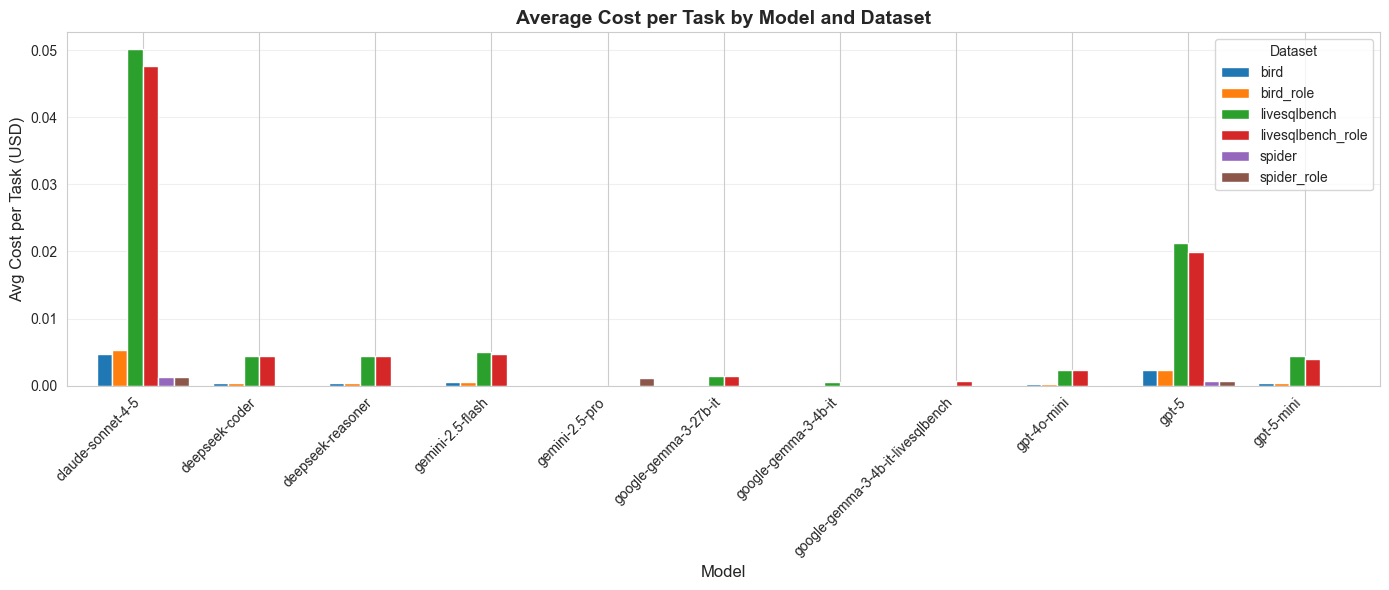

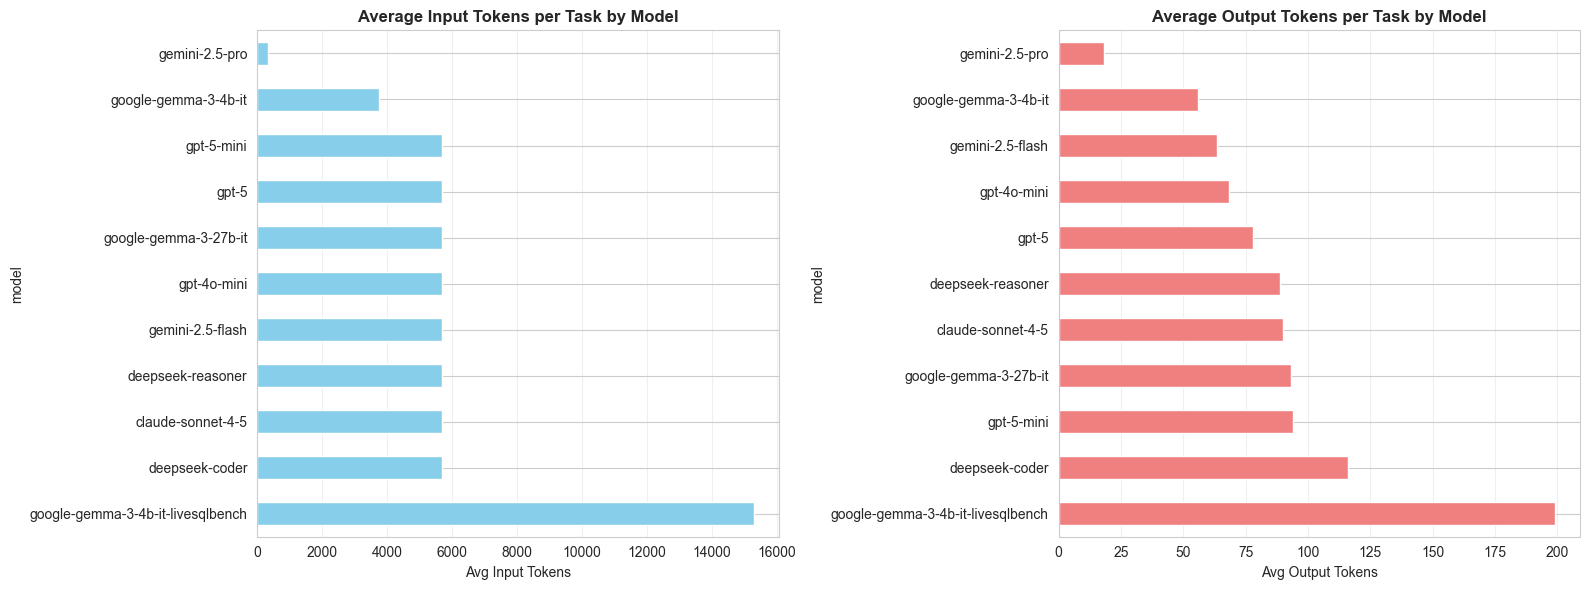

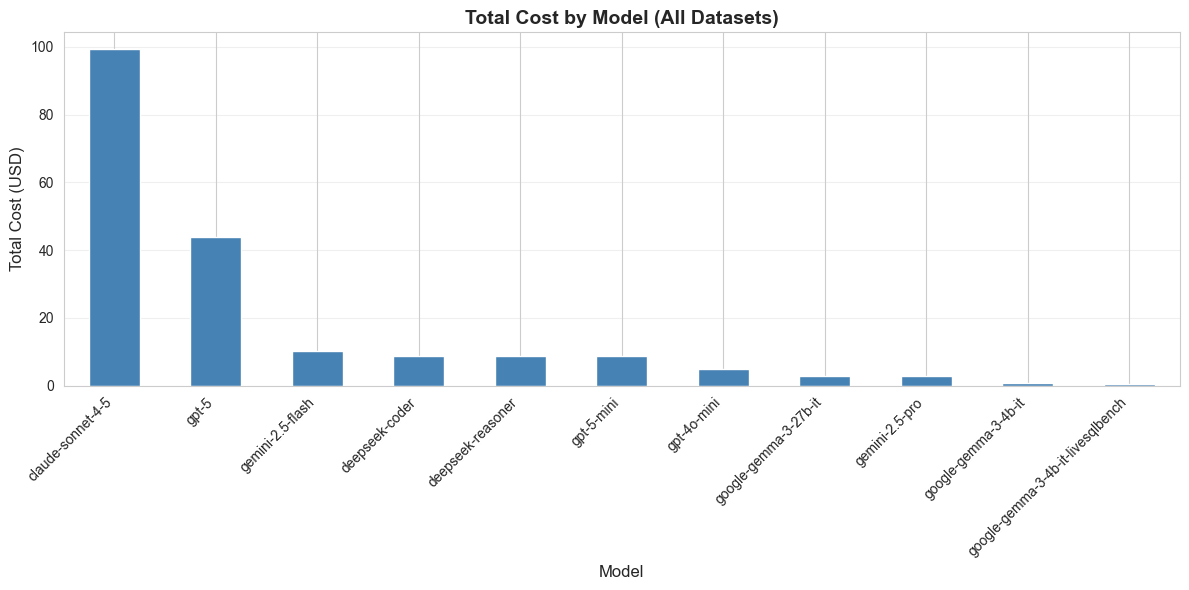

In [10]:
if len(cost_df) > 0:
    # 1. Average Cost per Task by Model and Dataset
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Pivot for grouped bar chart - use pivot_table to handle duplicates by averaging
    pivot_df = cost_df.pivot_table(
        index='model', 
        columns='dataset', 
        values='avg_cost_per_task_usd',
        aggfunc='mean'  # Average if there are duplicates
    )
    pivot_df.plot(kind='bar', ax=ax, width=0.8)
    
    ax.set_title('Average Cost per Task by Model and Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Avg Cost per Task (USD)', fontsize=12)
    ax.legend(title='Dataset', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # 2. Token Usage Comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Input tokens
    cost_df.groupby('model')['avg_input_tokens_per_task'].mean().sort_values(ascending=False).plot(
        kind='barh', ax=ax1, color='skyblue'
    )
    ax1.set_title('Average Input Tokens per Task by Model', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Avg Input Tokens')
    ax1.grid(axis='x', alpha=0.3)
    
    # Output tokens
    cost_df.groupby('model')['avg_output_tokens_per_task'].mean().sort_values(ascending=False).plot(
        kind='barh', ax=ax2, color='lightcoral'
    )
    ax2.set_title('Average Output Tokens per Task by Model', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Avg Output Tokens')
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Total Cost Comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    
    total_by_model = cost_df.groupby('model')['total_cost_usd'].sum().sort_values(ascending=False)
    total_by_model.plot(kind='bar', ax=ax, color='steelblue')
    
    ax.set_title('Total Cost by Model (All Datasets)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Total Cost (USD)', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for visualization")

In [11]:
# Check for duplicate model-dataset combinations
duplicates = cost_df[cost_df.duplicated(subset=['model', 'dataset'], keep=False)]
if len(duplicates) > 0:
    print("⚠️  Found duplicate model-dataset combinations:")
    print(duplicates[['model', 'dataset', 'num_tasks', 'avg_cost_per_task_usd']].sort_values(['model', 'dataset']))
    print(f"\nTotal duplicates: {len(duplicates)}")
else:
    print("✓ No duplicate model-dataset combinations found")

✓ No duplicate model-dataset combinations found


In [12]:
# Debug: Check what files produced the duplicate gpt-4o-mini/bird entries
gpt4o_mini_files = [f for f in pred_files if 'gpt-4o-mini' in f.name and 'bird' in f.name]
print(f"Found {len(gpt4o_mini_files)} gpt-4o-mini files with 'bird' in name:")
for f in gpt4o_mini_files:
    print(f"  - {f.name}")
    # Check which dataset it would be assigned to
    filename = f.name
    dataset_name = None
    if filename.endswith("_role.sql"):
        if "bird" in filename:
            dataset_name = "bird_role"
    elif "_role" not in filename:
        if "bird" in filename:
            dataset_name = "bird"
    print(f"    → Assigned to: {dataset_name}")

Found 3 gpt-4o-mini files with 'bird' in name:
  - pred_gpt-4o-mini_bird_role.sql
    → Assigned to: bird_role
  - pred_gpt-4o-mini_bird_rbac.sql
    → Assigned to: bird
  - pred_gpt-4o-mini_bird.sql
    → Assigned to: bird


## 8. Statistical Summary

In [13]:
if len(cost_df) > 0:
    print("=" * 100)
    print("STATISTICAL SUMMARY")
    print("=" * 100)
    
    # Overall statistics
    print("\n📊 Overall Statistics:")
    print(f"  Total unique models analyzed: {cost_df['model'].nunique()}")
    print(f"  Total datasets: {cost_df['dataset'].nunique()}")
    print(f"  Total model-dataset combinations: {len(cost_df)}")
    print(f"  Total tasks analyzed: {cost_df['num_tasks'].sum():.0f}")
    
    # Cost statistics
    print("\n💰 Cost Statistics:")
    print(f"  Total cost (all models & datasets): ${cost_df['total_cost_usd'].sum():.4f}")
    print(f"  Average cost per task (overall): ${cost_df['avg_cost_per_task_usd'].mean():.6f}")
    print(f"  Median cost per task: ${cost_df['avg_cost_per_task_usd'].median():.6f}")
    print(f"  Min cost per task: ${cost_df['avg_cost_per_task_usd'].min():.6f}")
    print(f"  Max cost per task: ${cost_df['avg_cost_per_task_usd'].max():.6f}")
    
    # Token statistics
    print("\n🔢 Token Statistics:")
    print(f"  Average input tokens per task: {cost_df['avg_input_tokens_per_task'].mean():.0f}")
    print(f"  Average output tokens per task: {cost_df['avg_output_tokens_per_task'].mean():.0f}")
    print(f"  Total input tokens: {cost_df['total_input_tokens'].sum():.0f}")
    print(f"  Total output tokens: {cost_df['total_output_tokens'].sum():.0f}")
    
    # Top 5 most expensive models
    print("\n💸 Top 5 Most Expensive Models (by avg cost per task):")
    top_expensive = cost_df.nlargest(5, 'avg_cost_per_task_usd')[
        ['model', 'dataset', 'avg_cost_per_task_usd', 'total_cost_usd']
    ]
    for idx, row in top_expensive.iterrows():
        print(f"  {row['model']} ({row['dataset']}): ${row['avg_cost_per_task_usd']:.6f}/task (total: ${row['total_cost_usd']:.4f})")
    
    # Top 5 most cost-efficient models
    print("\n💵 Top 5 Most Cost-Efficient Models (by avg cost per task):")
    top_efficient = cost_df.nsmallest(5, 'avg_cost_per_task_usd')[
        ['model', 'dataset', 'avg_cost_per_task_usd', 'total_cost_usd']
    ]
    for idx, row in top_efficient.iterrows():
        print(f"  {row['model']} ({row['dataset']}): ${row['avg_cost_per_task_usd']:.6f}/task (total: ${row['total_cost_usd']:.4f})")
    
    # By dataset
    print("\n📈 Cost by Dataset:")
    dataset_stats = cost_df.groupby('dataset').agg({
        'avg_cost_per_task_usd': 'mean',
        'total_cost_usd': 'sum',
        'num_tasks': 'sum'
    }).sort_values('avg_cost_per_task_usd', ascending=False)
    
    for dataset, row in dataset_stats.iterrows():
        print(f"  {dataset}: ${row['avg_cost_per_task_usd']:.6f}/task avg, ${row['total_cost_usd']:.4f} total ({row['num_tasks']:.0f} tasks)")
else:
    print("No data available for statistical summary")

STATISTICAL SUMMARY

📊 Overall Statistics:
  Total unique models analyzed: 11
  Total datasets: 6
  Total model-dataset combinations: 55
  Total tasks analyzed: 121623

💰 Cost Statistics:
  Total cost (all models & datasets): $191.8458
  Average cost per task (overall): $0.003799
  Median cost per task: $0.000559
  Min cost per task: $0.000013
  Max cost per task: $0.050139

🔢 Token Statistics:
  Average input tokens per task: 5580
  Average output tokens per task: 85
  Total input tokens: 276762828
  Total output tokens: 5097270

💸 Top 5 Most Expensive Models (by avg cost per task):
  claude-sonnet-4-5 (livesqlbench): $0.050139/task (total: $8.9247)
  claude-sonnet-4-5 (livesqlbench_role): $0.047688/task (total: $41.5835)
  gpt-5 (livesqlbench): $0.021298/task (total: $3.7910)
  gpt-5 (livesqlbench_role): $0.019937/task (total: $17.3851)
  claude-sonnet-4-5 (bird_role): $0.005258/task (total: $37.1722)

💵 Top 5 Most Cost-Efficient Models (by avg cost per task):
  google-gemma-3-4b-it 

## 9. Export Results

In [14]:
if len(cost_df) > 0:
    # Export to CSV
    output_dir = Path("dbgpt_hub_sql/output")
    output_dir.mkdir(exist_ok=True)
    
    csv_path = output_dir / "cost_analysis_report.csv"
    cost_df.to_csv(csv_path, index=False)
    print(f"✓ Cost analysis exported to: {csv_path}")
    
    # Export summary statistics
    summary_path = output_dir / "cost_summary.txt"
    with open(summary_path, 'w') as f:
        f.write("=" * 100 + "\n")
        f.write("LLM API COST ANALYSIS SUMMARY\n")
        f.write("=" * 100 + "\n\n")
        
        f.write("Overall Statistics:\n")
        f.write(f"  Total unique models: {cost_df['model'].nunique()}\n")
        f.write(f"  Total datasets: {cost_df['dataset'].nunique()}\n")
        f.write(f"  Total tasks: {cost_df['num_tasks'].sum():.0f}\n\n")
        
        f.write("Cost Statistics:\n")
        f.write(f"  Total cost: ${cost_df['total_cost_usd'].sum():.4f}\n")
        f.write(f"  Average cost per task: ${cost_df['avg_cost_per_task_usd'].mean():.6f}\n")
        f.write(f"  Median cost per task: ${cost_df['avg_cost_per_task_usd'].median():.6f}\n\n")
        
        f.write("Top 5 Most Expensive Models:\n")
        top_expensive = cost_df.nlargest(5, 'avg_cost_per_task_usd')
        for idx, row in top_expensive.iterrows():
            f.write(f"  {row['model']} ({row['dataset']}): ${row['avg_cost_per_task_usd']:.6f}/task\n")
        
        f.write("\nTop 5 Most Cost-Efficient Models:\n")
        top_efficient = cost_df.nsmallest(5, 'avg_cost_per_task_usd')
        for idx, row in top_efficient.iterrows():
            f.write(f"  {row['model']} ({row['dataset']}): ${row['avg_cost_per_task_usd']:.6f}/task\n")
    
    print(f"✓ Summary statistics exported to: {summary_path}")
    
    # Export detailed Excel file (if openpyxl is available)
    try:
        excel_path = output_dir / "cost_analysis_detailed.xlsx"
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            cost_df.to_excel(writer, sheet_name='Detailed Analysis', index=False)
            
            # Add summary sheet
            summary_df = cost_df.groupby('model').agg({
                'avg_cost_per_task_usd': 'mean',
                'total_cost_usd': 'sum',
                'num_tasks': 'sum',
                'avg_input_tokens_per_task': 'mean',
                'avg_output_tokens_per_task': 'mean'
            }).reset_index()
            summary_df.to_excel(writer, sheet_name='Summary by Model', index=False)
            
        print(f"✓ Detailed Excel report exported to: {excel_path}")
    except ImportError:
        print("  Note: Install openpyxl to export Excel files (pip install openpyxl)")
    
    print("\n" + "=" * 100)
    print("✅ COST ANALYSIS COMPLETE")
    print("=" * 100)
else:
    print("No data to export")

✓ Cost analysis exported to: dbgpt_hub_sql/output/cost_analysis_report.csv
✓ Summary statistics exported to: dbgpt_hub_sql/output/cost_summary.txt
  Note: Install openpyxl to export Excel files (pip install openpyxl)

✅ COST ANALYSIS COMPLETE
